## 4. Pytorch custom datasets video notebook

**Resources:**

* ipynb notebook : https://github.com/mrdbourke/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets.ipynb

* Slides : https://www.learnpytorch.io/04_pytorch_custom_datasets/

In [2]:
import torch
from torch import nn


In [3]:
#Device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 4.1 Get data

The dataset is a subset of the Food101 dataset.

It is scaled down to 3 classes and 10% of the images

In [4]:
import requests
import zipfile
from pathlib import Path

#Setup path to a datafolder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

#if the image folder does not exist , download and prepare it 
if image_path.is_dir():
    print(f"{image_path} Directory already exists... skipping download")
else:
    print(f"{image_path} does not exist creating one")
    image_path.mkdir(parents= True,exist_ok = True)
    #Download the dataset
    with open(data_path/"pizza_steak_sushi.zip","wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza steak sushi data")
        f.write(request.content)
    #Unzip pizza steak sushi file
    with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
        print("Unzipping pizza steak sushi data...")
        zip_ref.extractall(image_path) 



        

data\pizza_steak_sushi Directory already exists... skipping download


## 4.2 Data preparation and Data exploration

In [5]:
import os 
def walk_through_dir(dir_path):
    """Walks thorugh dir path returning its content"""
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")


In [6]:
#Setup train and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir ,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

## 4.3 Visualizing

1. Get all the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working with images ,Let's open the image with python's pil library
5. Show the image and print metadata

Random image path : data\pizza_steak_sushi\test\sushi\2394442.jpg
Image class : sushi
Image height : 408
Image width : 512


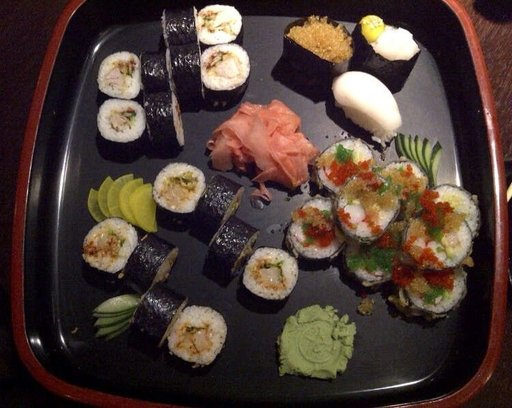

In [7]:
import random
from PIL import Image
#Set the seed 
random.seed(42)
#1.Get all image path
image_path_list = list(image_path.glob("*/*/*.jpg")) 
#*/*/* means go through any directory example: data/pizza_Steak_sushi/test and train
#2. Pick  a random image path 
random_image_path = random.choice(image_path_list)


#3. Get the image class from the path name 
image_class = random_image_path.parent.stem


#4.Open image
img = Image.open(random_image_path)

#5.Print metadata
print(f"Random image path : {random_image_path}")
print(f"Image class : {image_class}")
print(f"Image height : {img.height}")
print(f"Image width : {img.width}")
img

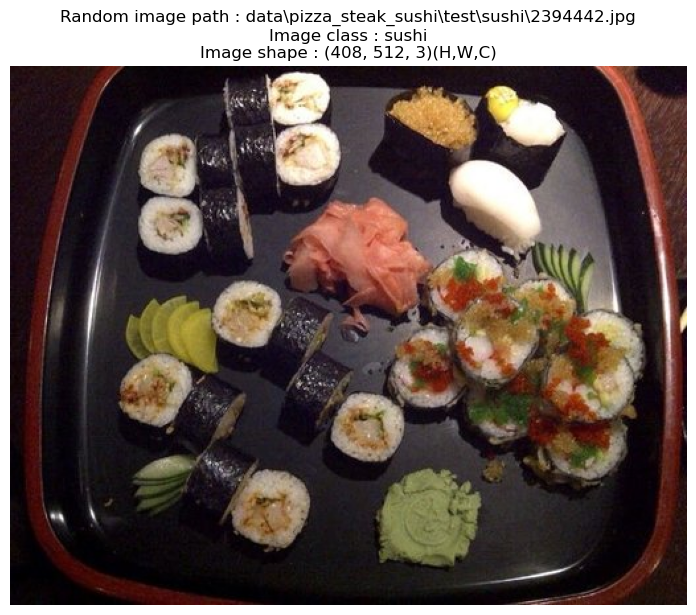

In [8]:
import numpy as np 
import matplotlib.pyplot as plt

#Turn the image into an array
img_arr = np.asarray(img)

#Plot the image woth matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_arr)
plt.title(f"Random image path : {random_image_path}\nImage class : {image_class}\nImage shape : {img_arr.shape}(H,W,C)")
plt.axis(False)
plt.show()
 

## 3. Transforming data 

1.Turn the target data into tensors

2.Turn it into a `torch.utils.data.Dataset` and a `torch.utils.data.DataLoader` i.e `Dataset` and `Dataloader`

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms


## 3.1 Transforming data with `torchvision.transforms`

In [10]:
#Write a transform for the images
data_transform = transforms.Compose([
    #Resize our images to 64 * 64
    transforms.Resize(size=(64,64)),
    #Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [11]:
data_transform(img).shape

torch.Size([3, 64, 64])

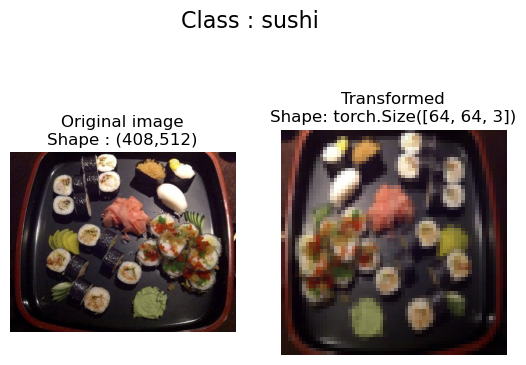

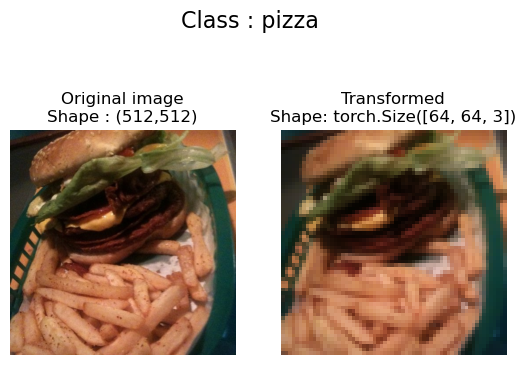

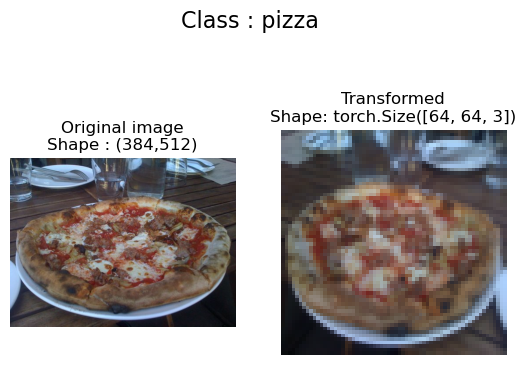

In [12]:
def plot_transformed_img(image_paths:list,transform,n =3,seed = 42 ):
    """
    Selects random images from a path of images and load/transforms
    them then plots the original vs the trasnformed data
    """
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(nrows = 1 ,ncols = 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original image\nShape : ({f.height},{f.width})")
            ax[0].axis(False)

            #Transform and plot target images
            transformed_image = transform(f).permute(1,2,0)#we will need to change the shape for matplotlib
            #permute() used for rearranging all the dimensions it takes indexes of the dim as input
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis(False)   

            fig.suptitle(f"Class : {image_path.parent.stem}",fontsize = 16)

plot_transformed_img(image_paths = image_path_list,transform=data_transform,n=3,seed=42)



## 4. Option 1 : Loading image data using `ImageFolder`

We can load image classification data using `torchvision.datasets.ImageFolder` - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html

In [13]:
from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,transform=data_transform,target_transform=None)

test_data = datasets.ImageFolder(root= test_dir,transform=data_transform,target_transform= None)
train_data

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [14]:
test_data

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [15]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [16]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [17]:
#Check the lenghts of our dataset
len(train_data),len(test_data)

(225, 75)

In [18]:
train_data.samples[0]

('data\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0)

In [19]:
#Index on the train_data Dataset to get a single image and label
img,label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype : {img.dtype}")
print(f"Image label datatype : {type(label)}")

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

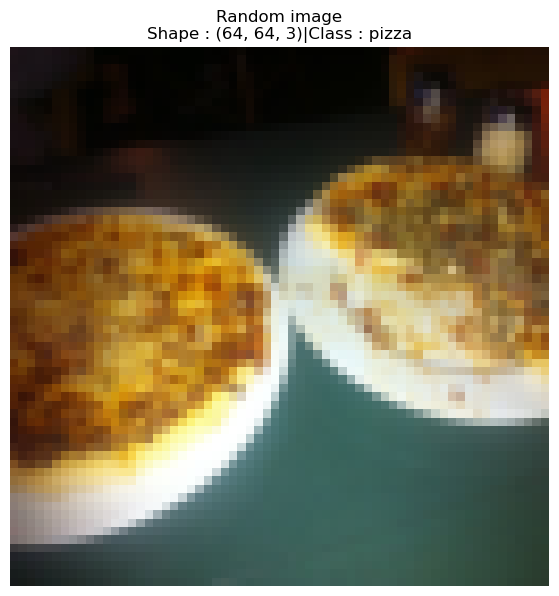

In [20]:
#Plotting the img on matplot lib

#Rearranging the indexes

img_permute = img.permute(1,2,0)
img_arr = np.asarray(img_permute)
plt.figure(figsize=(10,7))
plt.imshow(img_arr)
plt.title(f"Random image\nShape : {img_arr.shape}|Class : {class_names[label]}")
plt.axis(False)

## 4.1 Turn loaded images into `Dataloaders`

A `Dataloader` is going to help us turn our Dataset into iterables and we can customise the `batch_size` so our model can see `batch_size` iamges at a time


In [21]:
import os 
os.cpu_count()

16

In [22]:
#Turn train and test datasets into Dataloader's
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,batch_size=BATCH_SIZE,num_workers= 8 ,shuffle = True)
test_dataloader = DataLoader(dataset=test_data,batch_size=BATCH_SIZE,num_workers= 8 ,shuffle = True)


In [23]:
len(train_dataloader) , len(test_dataloader)

(8, 3)

In [24]:
img,label = next(iter(train_dataloader))

In [25]:
print(f"Image shape : {img.shape} -> [batch_size,color_channels,height,width]")
print(f"Label shape : {label.shape}")

Image shape : torch.Size([32, 3, 64, 64]) -> [batch_size,color_channels,height,width]
Label shape : torch.Size([32])


## 5. Option 2 Loading image Data with a custom `Dataset`
1. Want to be able to load images from file
2. Watn to be able to get class names from the Dataset 
3. Want to be able to get classes as dictionary from the Dataset

Pros:

1. Can create a `Dataset` out of almsot anything 
2. Not limited to pytorch pre-built `Datset` functions

Cons:
1. Even though you could create `Dataset` out of almost anything , it does not mean it will work

2. Using a custom  `Datset` requires to write more code

In [26]:
import os 
import pathlib as Path
import torch
from PIL import Image
from torch.utils.data  import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

In [27]:
#Instance of torchvision.datasets.ImageFolder()
test_data.classes ,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.1 Creating a helper fucntion to get class names

1. Get the class names using `os.scandir()` to traverse target direcotory 

2. Raise an error if class names are not found  

3. Turn the class names into a dict and a list and return them 
 

In [28]:
#Setup path for target directory
target_directory = train_dir
print(f"Target dir : {target_directory}")

#Get the class names fromt the target directory 
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found



Target dir : data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [34]:
def find_classes(directory:str) -> [Tuple[List[str]],Dict[str,int]]:
    """
    Finds the class folder names in a target directory.
    """
    #1.Get the class name by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    #2.Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Could not find any classes in the {directory}\nPlease check file structure")
    #3.Create a dictionaey of index labels
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes,class_to_idx


In [35]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`

2.Init our subclass with a target directory as well as a trasnform

3.Create several attributes:
    
    a. Paths
    
    b. Transform
    
    c. classes
    
    d. class_to_idx

4. Create a fucntion to `load_images()`, this function will open an image

5.Overwrite the `__len()__` method to return the length of our datasets
